# Network Intrusion Lab

O objetivo é prever Label: 0 = benigno; 1 = ataque, usando o dataset de [Rebson Ramalho](https://www.kaggle.com/datasets/rebsonramalho/network-threat-detection-dataset), disponível no Kaggle.

O experimento principal usa `Dataset_resumido.csv`, versão 2, para facilitar a execução em CPU.

- Pergunta: o modelo distingue os rótulos em conexões reservadas para teste? Quanto do resultado pode estar relacionado à ausência de dados e às características do laboratório?

O exemplo disponibilizado na página do conjunto de dados é um notebook que classifica registros de autenticação SSH com Random Forest, comparação de modelos e busca de hiperparâmetros. Esse notebook não utiliza os dados de rede deste trabalho, pois carrega outro conjunto de dados. O Random Forest é mantido como modelo principal, aplicado à versão resumida do conjunto de dados, com protocolo de avaliação distinto.

## 1. Fundamentação e escolha do exemplo

Escolhi o Random Forest, um classificador baseado em árvores de decisão, tomando como referência o trabalho de [Carneiro et al. (2021)](https://arxiv.org/abs/2107.02753), que compara Random Forest e K-Nearest Neighbours no CIDDS-001 com dois tipos de rótulo. Essa comparação orientou a minha atenção à escolha do rótulo.

[Sommer e Paxson (2010)](https://ieeexplore.ieee.org/document/5504793) motivam investigar erros, artefatos e limites de transferência para outras redes. [Shibly et al. (2026)](https://salford-repository.worktribe.com/output/5519187/empirical-bernstein-certified-bandit-kl-mixing-with-tree-stacking-for-explainable-federated-intrusion-detection) declaram usar a mesma base deste notebook em um cenário federado, com quatro clientes, divisões locais enviesadas e modelos em árvore. Esse protocolo difere do teste centralizado deste trabalho, então os resultados não são comparáveis diretamente.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import ipaddress
import json
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, precision_recall_curve, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

SEED = 42
THRESHOLD = 0.5
N_JOBS = 2
DATASET_NAME = 'Dataset_resumido.csv'
SHA256 = {DATASET_NAME: 'bd775a4e982055794c8feda3d4cfcb7ddcea1c4d4e4c4048f0cfcaf8bcd23445'}

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
OUTPUT_ROOT = PROJECT_ROOT

FIGURES = OUTPUT_ROOT / 'reports/figures'
RESULTS = OUTPUT_ROOT / 'reports/results'

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 180})
COLORS = {'benigno': '#167d8d', 'ataque': '#db654b', 'principal': '#324a7b'}


def save_figure(name):
    plt.savefig(FIGURES / name, bbox_inches='tight')
    plt.show()


environment = {
    'python': platform.python_version(),
    'numpy': np.__version__,
    'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__,
}

## 2. Leitura e integridade dos dados

O download é realizado por `python scripts/download_data.py`, sem credenciais no código. 

O CSV completo tem mais registros e forte predominância de ataques. Não usei um CSV para treinar e o outro para demonstrar generalização independente.

In [2]:
DATA_PATH = PROJECT_ROOT / 'data/raw' / DATASET_NAME

if not DATA_PATH.is_file():
    raise FileNotFoundError(f'{DATA_PATH} não encontrado. Rode: python scripts/download_data.py')

data_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
if data_hash != SHA256[DATASET_NAME]:
    raise ValueError('Hash diferente da versão 2. Revise a versão antes de executar o experimento.')

raw = pd.read_csv(DATA_PATH, low_memory=False)
source_columns = list(raw.columns)
raw['_row_id'] = np.arange(len(raw))
print(f'Arquivo: {DATA_PATH.name} | linhas: {len(raw):,} | colunas no CSV (sem Label): {len(source_columns) - 1}')

Arquivo: Dataset_resumido.csv | linhas: 55,826 | colunas no CSV (sem Label): 24


## 3. Auditoria: duplicatas, ausências e semântica

O nome de uma coluna não garante seu conteúdo. Nesta base, `trans_depth` inclui GET e POST, `res_bdy_len` inclui URLs e `ct_state_ttl` inclui estados TCP. Por isso, não converti esses campos automaticamente para números. Também há timestamps e indicadores booleanos em campos que lembram variáveis de outros benchmarks.

Removi apenas duplicatas exatas, sem eliminar exemplos difíceis nem rótulos conflitantes. Sendo uma inspeção exploratória e descritiva.

Duplicatas exatas removidas: 5,572; registros restantes: 50,254


,dtype_csv,n_unicos,ausentes_pct
srcip,object,21,0.000000
sport,float64,16506,0.959128
dstip,object,44,0.000000
dsport,float64,6764,0.959128
proto,object,4,0.000000
state,object,3,34.986270
dur,float64,20953,34.986270
sbytes,float64,1244,34.604211
dbytes,float64,3266,34.604211
service,object,12,68.704979


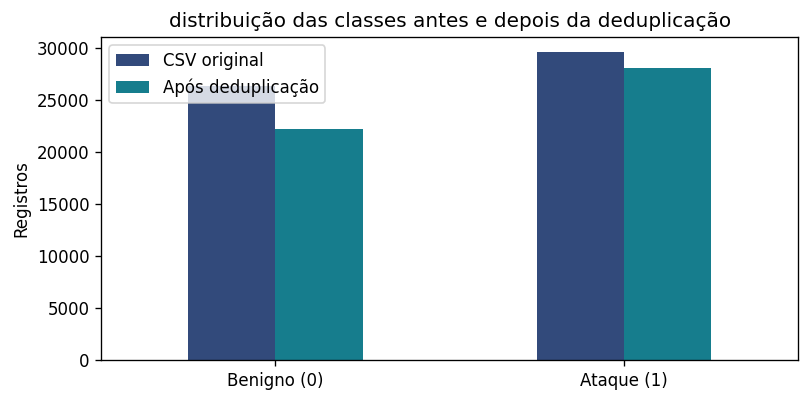

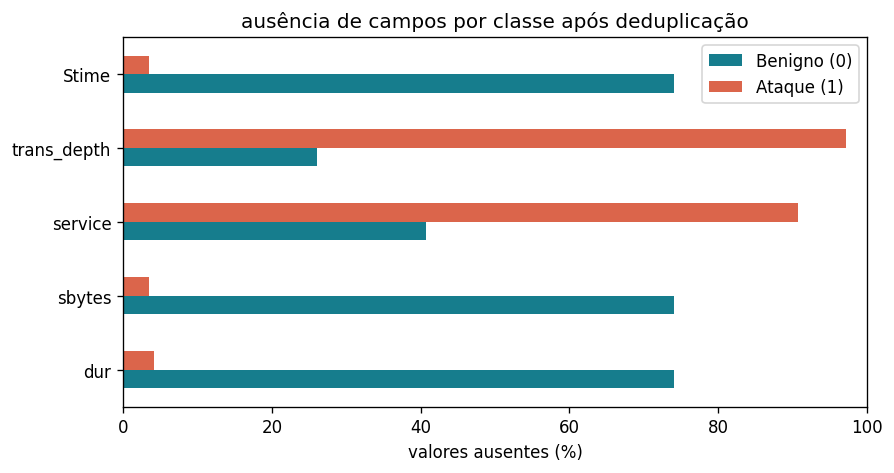

In [3]:
n_duplicates = int(raw.duplicated(subset=source_columns).sum())
df = raw.drop_duplicates(subset=source_columns).reset_index(drop=True)
print(f'Duplicatas exatas removidas: {n_duplicates:,}; registros restantes: {len(df):,}')

audit = pd.DataFrame({
    'dtype_csv': df[source_columns].dtypes.astype(str),
    'n_unicos': df[source_columns].nunique(),
    'ausentes_pct': df[source_columns].isna().mean() * 100,
})
display(audit)

counts = pd.DataFrame({'CSV original': raw.Label.value_counts(), 'Após deduplicação': df.Label.value_counts()}).sort_index()
counts.index = ['Benigno (0)', 'Ataque (1)']
ax = counts.plot.bar(color=[COLORS['principal'], COLORS['benigno']], figsize=(7.5, 3.5), rot=0)
ax.set(ylabel='Registros', title='distribuição das classes antes e depois da deduplicação', xlabel='')
save_figure('01_class_distribution.png')

missing_by_class = df.groupby('Label')[source_columns[:-1]].agg(lambda c: c.isna().mean()).T * 100
missing_by_class.columns = ['Benigno (0)', 'Ataque (1)']

ax = missing_by_class.loc[['dur', 'sbytes', 'service', 'trans_depth', 'Stime']].plot.barh(
    figsize=(8, 4), color=[COLORS['benigno'], COLORS['ataque']]
)

ax.set(title='ausência de campos por classe após deduplicação', xlabel='valores ausentes (%)', xlim=(0, 100))
save_figure('02_missingness_by_class.png')

## 4. Atributos e grupos de conexão

Usei nove medidas de tráfego e quatro variáveis categóricas. IPs e portas servem apenas para formar os grupos de conexão, e os timestamps ficam fora do classificador. Excluir portas dos atributos é uma escolha prudente para reduzir atalhos do laboratório, com possível perda de informação útil. Métodos HTTP e URLs exigiriam outro experimento com schema próprio.

O grupo usa o protocolo e o par de endpoints (IP, porta), sem distinguir origem e destino. É uma aproximação de conexão, pois pode unir conexões com portas reutilizadas e não agrupa todos os fluxos de uma campanha de ataque. Isso reduz o compartilhamento direto de conexões entre as partições, mas não garante ausência de toda dependência, nem testa ataques atípicos ou outra rede.

In [4]:
NUMERIC = ['dur', 'sbytes', 'dbytes', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'smeansz', 'dmeansz']
CATEGORICAL = ['proto', 'state', 'service', 'ct_state_ttl']
FEATURES = NUMERIC + CATEGORICAL


def normalize_protocol(series):
    return (series.astype('string').str.strip().str.upper().replace(
        {'6': 'TCP', '6.0': 'TCP', '17': 'UDP', '17.0': 'UDP', '1': 'ICMP', '1.0': 'ICMP', '58': 'IPV6-ICMP', '58.0': 'IPV6-ICMP'}
        ))


def normalize_ip(value):
    value = str(value).strip()
    try:
        return ipaddress.ip_address(value).compressed
    except ValueError:
        return value


def conversation_groups(frame):
    def port(value):
        return '*' if pd.isna(value) else str(int(value))
    
    protocol = normalize_protocol(frame['proto'])
    keys = []

    for src, sp, dst, dp, pr in zip(frame.srcip, frame.sport, frame.dstip, frame.dsport, protocol):
        endpoints = sorted([(normalize_ip(src), port(sp)), (normalize_ip(dst), port(dp))])
        keys.append(json.dumps([str(pr), endpoints], separators=(',', ':')))

    return pd.factorize(np.asarray(keys, dtype=object), sort=True)[0]


X = df[FEATURES].copy()

conversion_failures = {}
for col in NUMERIC:
    converted = pd.to_numeric(X[col], errors='coerce')
    conversion_failures[col] = int((converted.isna() & X[col].notna()).sum())
    X[col] = converted.replace([np.inf, -np.inf], np.nan)

for col in CATEGORICAL:
    s = normalize_protocol(X[col]) if col == 'proto' else X[col].astype('string').str.strip().str.upper()
    s = s.replace({'': pd.NA})
    X[col] = s.astype(object).where(s.notna(), np.nan)
    
y = df.Label.copy()
groups = conversation_groups(df)
feature_hash = pd.util.hash_pandas_object(X, index=False).to_numpy()
label_conflicts = int(pd.DataFrame({'hash': feature_hash, 'y': y}).groupby('hash').y.nunique().gt(1).sum())
print('Atributos:', FEATURES)
print(f'Grupos de conexão: {len(np.unique(groups)):,}')
print(f'Representações idênticas de atributos com rótulos diferentes: {label_conflicts}')

Atributos: ['dur', 'sbytes', 'dbytes', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'smeansz', 'dmeansz', 'proto', 'state', 'service', 'ct_state_ttl']
Grupos de conexão: 31,567
Representações idênticas de atributos com rótulos diferentes: 39


## 5. Partições de treino, validação e teste separadas por grupos

O primeiro fold de uma divisão estratificada por grupos em cinco folds é reservado para teste. Entre os folds restantes, o primeiro fold de nova divisão em cinco é reservado para validação. As proporções nominais são de aproximadamente 64% / 16% / 20%, o agrupamento pode alterar as proporções efetivas, e a estratificação é aproximada. Não foi buscada outra semente após a observação dos scores.

O conjunto de teste não participa do ajuste nem da seleção. Imputação, codificação e escala são aprendidas somente no treino, dentro de um pipeline. Não se aplica SMOTE. As verificações a seguir interrompem a execução se uma conexão aparecer em mais de uma partição.

A igualdade de atributos entre conexões diferentes não implica vazamento automaticamente. Sua frequência é quantificada aqui, e uma fatia de configurações originais é avaliada na seção 9.

In [5]:
from itertools import combinations

outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
pool_idx, test_idx = next(outer.split(X, y, groups))
inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
train_local, val_local = next(inner.split(X.iloc[pool_idx], y.iloc[pool_idx], groups[pool_idx]))
train_idx, val_idx = pool_idx[train_local], pool_idx[val_local]
PARTITIONS = {'treino': train_idx, 'validacao': val_idx, 'teste': test_idx}

for name, idx in PARTITIONS.items():
    assert set(y.iloc[idx]) == {0, 1}, f'{name} não contém ambas as classes.'
for (a, ia), (b, ib) in combinations(PARTITIONS.items(), 2):
    assert not set(ia) & set(ib), f'linhas compartilhadas entre {a} e {b}.'
    assert not set(groups[ia]) & set(groups[ib]), f'grupos compartilhados entre {a} e {b}.'
assert sum(map(len, PARTITIONS.values())) == len(df)

split_table = pd.DataFrame([
    {'particao': name, 'registros': len(idx), 'percentual': 100 * len(idx) / len(df),
     'grupos': len(np.unique(groups[idx])), 'benignos': int((y.iloc[idx] == 0).sum()),
     'ataques': int((y.iloc[idx] == 1).sum())}
    for name, idx in PARTITIONS.items()
])
display(split_table.round(2))
split_table.to_csv(RESULTS / 'split_summary.csv', index=False)

overlap = []
for name in ['validacao', 'teste']:
    seen = np.isin(feature_hash[PARTITIONS[name]], feature_hash[train_idx])
    overlap.append({'particao': name, 'registros_com_atributos_iguais_ao_treino': int(seen.sum()),'percentual': 100 * seen.mean()})

display(pd.DataFrame(overlap).round(2))

X_train, X_val, X_test = X.iloc[train_idx], X.iloc[val_idx], X.iloc[test_idx]
y_train, y_val, y_test = y.iloc[train_idx], y.iloc[val_idx], y.iloc[test_idx]

,particao,registros,percentual,grupos,benignos,ataques
0,treino,32162,64.0,20202,14185,17977
1,validacao,8041,16.0,5052,3546,4495
2,teste,10051,20.0,6313,4433,5618


,particao,registros_com_atributos_iguais_ao_treino,percentual
0,validacao,4976,61.88
1,teste,6175,61.44


## 6. Baselines e seleção de Random Forest na validação

São treinadas uma referência de classe majoritária, uma regressão logística e três configurações pré-definidas de Random Forest. A seleção ocorre *somente entre as três Random Forests*, pelo maior Macro-F1 na validação e, em caso de empate, mantém-se a primeira configuração, a mais restrita. Os demais modelos servem de referência. Os pesos de classe são calculados no treino.

Mantém-se o limiar de 0,5, sem otimização sobre o teste. O Macro-F1 atribui o mesmo peso às duas classes. A configuração escolhida permanece treinada apenas no treino, sem novo ajuste após a validação, para manter simples a interpretação da execução.

In [6]:
def make_preprocessor(scale=False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median', add_indicator=True, keep_empty_features=True))]
    if scale:
        numeric_steps.append(('scaler', StandardScaler()))

    categorical_steps = [
        ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING', keep_empty_features=True)),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]

    return ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), NUMERIC),
        ('categorical', Pipeline(categorical_steps), CATEGORICAL),
    ])


def metrics(y_true, prediction, probability=None):
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    result = {
        'accuracy': accuracy_score(y_true, prediction),
        'balanced_accuracy': balanced_accuracy_score(y_true, prediction),
        'precision_attack': precision_score(y_true, prediction, pos_label=1, zero_division=0),
        'recall_attack': recall_score(y_true, prediction, pos_label=1, zero_division=0),
        'f1_attack': f1_score(y_true, prediction, pos_label=1, zero_division=0),
        'macro_f1': f1_score(y_true, prediction, labels=[0, 1], average='macro', zero_division=0),
        'false_positive_rate': fp / (fp + tn) if fp + tn else np.nan,
        'false_negative_rate': fn / (fn + tp) if fn + tp else np.nan,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }

    if probability is not None and len(np.unique(y_true)) == 2:
        result.update({
            'roc_auc': roc_auc_score(y_true, probability),
            'average_precision': average_precision_score(y_true, probability),
            'brier_score': brier_score_loss(y_true, probability),
        })

    return result


rf_configs = [
    {'max_depth': 12, 'min_samples_leaf': 2},
    {'max_depth': None, 'min_samples_leaf': 2},
    {'max_depth': None, 'min_samples_leaf': 1},
]

models = {
    'Dummy_majoritaria': Pipeline([
        ('preprocess', make_preprocessor()),
        ('classifier', DummyClassifier(strategy='most_frequent')),
    ]),

    'Regressao_logistica': Pipeline([
        ('preprocess', make_preprocessor(scale=True)),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED)),
    ]),
}

for i, config in enumerate(rf_configs, start=1):
    models[f'RandomForest_{i}'] = Pipeline([
        ('preprocess', make_preprocessor()),
        ('classifier', RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=SEED, n_jobs=N_JOBS, **config)),
    ])

validation_records = []
for name, estimator in models.items():
    start = time.perf_counter()
    estimator.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start
    probability = estimator.predict_proba(X_val)[:, 1]
    prediction = (probability >= THRESHOLD).astype('int8')
    record = {'model': name, 'train_seconds': train_seconds, **metrics(y_val, prediction, probability)}
    validation_records.append(record)
    print(f"{name}: Macro-F1 validação = {record['macro_f1']:.4f} | treino = {train_seconds:.2f}s")

validation = pd.DataFrame(validation_records)
rf_validation = validation[validation.model.str.startswith('RandomForest')]
selected_name = rf_validation.loc[rf_validation.macro_f1.idxmax(), 'model']
selected = models[selected_name]
selected_config = selected.named_steps['classifier'].get_params()
display(validation[['model', 'accuracy', 'balanced_accuracy', 'macro_f1', 'recall_attack', 'train_seconds']].round(4))
print('Configuração escolhida:', selected_name, selected_config['max_depth'], selected_config['min_samples_leaf'])
validation.to_csv(RESULTS / 'validation_metrics.csv', index=False)

Dummy_majoritaria: Macro-F1 validação = 0.3586 | treino = 0.09s
Regressao_logistica: Macro-F1 validação = 0.9675 | treino = 2.95s
RandomForest_1: Macro-F1 validação = 0.9742 | treino = 0.71s
RandomForest_2: Macro-F1 validação = 0.9744 | treino = 0.67s
RandomForest_3: Macro-F1 validação = 0.9741 | treino = 0.72s


,model,accuracy,balanced_accuracy,macro_f1,recall_attack,train_seconds
0,Dummy_majoritaria,0.5590,0.5000,0.3586,1.0000,0.0940
1,Regressao_logistica,0.9678,0.9698,0.9675,0.9531,2.9514
2,RandomForest_1,0.9745,0.9762,0.9742,0.9615,0.7083
3,RandomForest_2,0.9746,0.9764,0.9744,0.9615,0.6688
4,RandomForest_3,0.9744,0.9762,0.9741,0.9608,0.7228


Configuração escolhida: RandomForest_2 None 2


## 7. Diagnóstico de ausência de campos e explicação global

O diagnóstico utiliza somente flags de ausência, sem bytes, pacotes ou valores de protocolo. Uma árvore pequena aprende a prever os rótulos a partir dessas flags. Bom desempenho nesse controle sugere que a disponibilidade dos campos contém informação forte sobre o rótulo, mas não prova, isoladamente, que toda previsão da Random Forest seja um atalho.

A importância por permutação é calculada na validação, após a seleção, sem alteração da configuração. Ela mede a queda de Macro-F1 ao embaralhar uma coluna. Não estabelece causalidade. Correlações e redundância podem reduzir a importância aparente.

Controle de ausências, Macro-F1 na validação: 0.9618


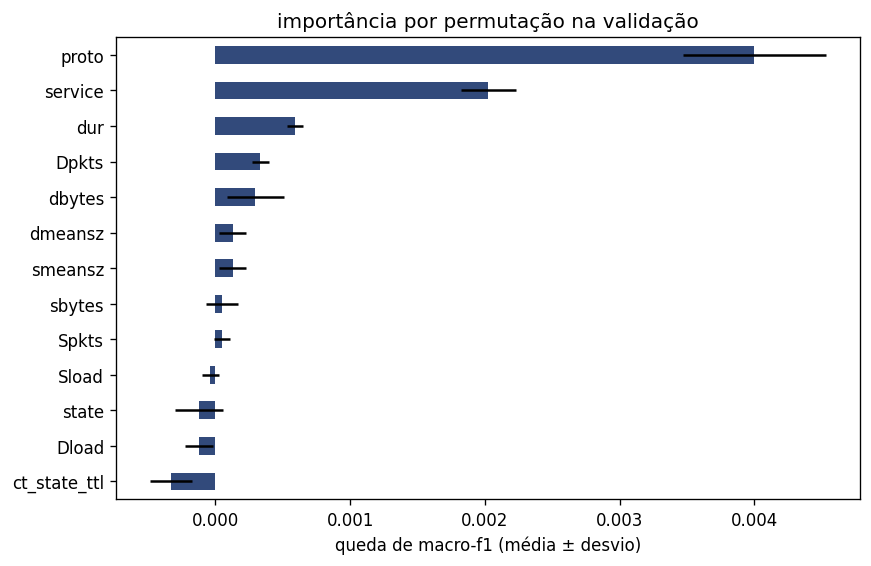

In [7]:
def missing_flags(frame):
    return frame.isna().astype('uint8')


missingness_model = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, class_weight='balanced', random_state=SEED)

missingness_model.fit(missing_flags(X_train), y_train)

missing_val_prob = missingness_model.predict_proba(missing_flags(X_val))[:, 1]

missing_val_metrics = metrics(y_val, (missing_val_prob >= THRESHOLD).astype('int8'), missing_val_prob)

print('Controle de ausências, Macro-F1 na validação:', round(missing_val_metrics['macro_f1'], 4))

importance = permutation_importance(selected, X_val, y_val, scoring='f1_macro', n_repeats=3, random_state=SEED, n_jobs=1)

importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance_mean': importance.importances_mean,
    'importance_std': importance.importances_std,
}).sort_values('importance_mean')

importance_df.to_csv(RESULTS / 'permutation_importance_validation.csv', index=False)

ax = importance_df.plot.barh(x='feature', y='importance_mean', xerr='importance_std', figsize=(8, 5), color=COLORS['principal'], legend=False)
ax.set(title='importância por permutação na validação', xlabel='queda de macro-f1 (média ± desvio)', ylabel='')
save_figure('03_permutation_importance.png')

## 8. Avaliação final no teste reservado

Os scores de teste são consultados somente nesta etapa. A tabela compara as referências, a Random Forest selecionada e o controle de ausências. Nenhum outro modelo é escolhido após esta tabela. O escopo das métricas é a classificação dos registros desta coleta, elas não validam um IDS em produção nem demonstram a detecção de famílias de ataque ausentes do treino.

**Precisão de ataque = TP/(TP+FP); recall = TP/(TP+FN)**

A taxa de falso positivo usa todos os benignos no denominador. A Average Precision é reportada como AP, e não como área trapezoidal da curva PR. O Brier score descreve o erro das probabilidades, o modelo não é calibrado.

,model,accuracy,balanced_accuracy,macro_f1,precision_attack,recall_attack,false_positive_rate,average_precision
0,Dummy_majoritaria,0.5589,0.5000,0.3585,0.5589,1.0000,1.0000,0.5589
1,Regressao_logistica,0.9716,0.9734,0.9714,0.9903,0.9587,0.0120,0.9884
2,RandomForest_2,0.9763,0.9779,0.9761,0.9929,0.9646,0.0088,0.9903
3,Controle_ausencias,0.9650,0.9679,0.9647,0.9942,0.9429,0.0070,0.9830


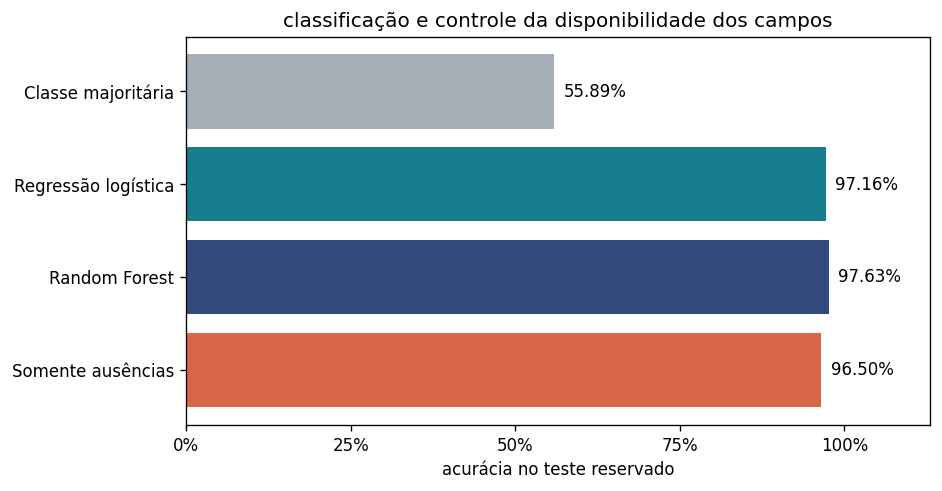

,precision,recall,f1-score,support
Benigno,0.9567,0.9912,0.9736,4433.0000
Ataque,0.9929,0.9646,0.9785,5618.0000
accuracy,0.9763,0.9763,0.9763,0.9763
macro avg,0.9748,0.9779,0.9761,10051.0000
weighted avg,0.9769,0.9763,0.9764,10051.0000


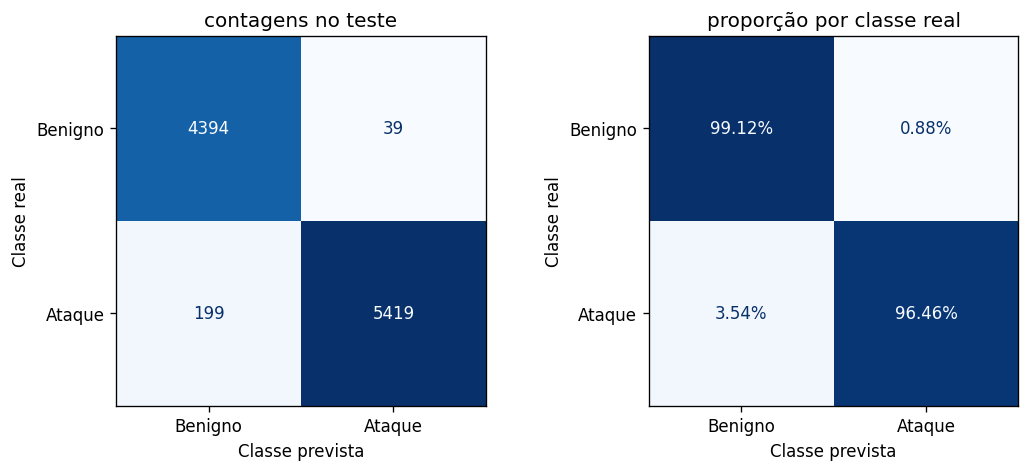

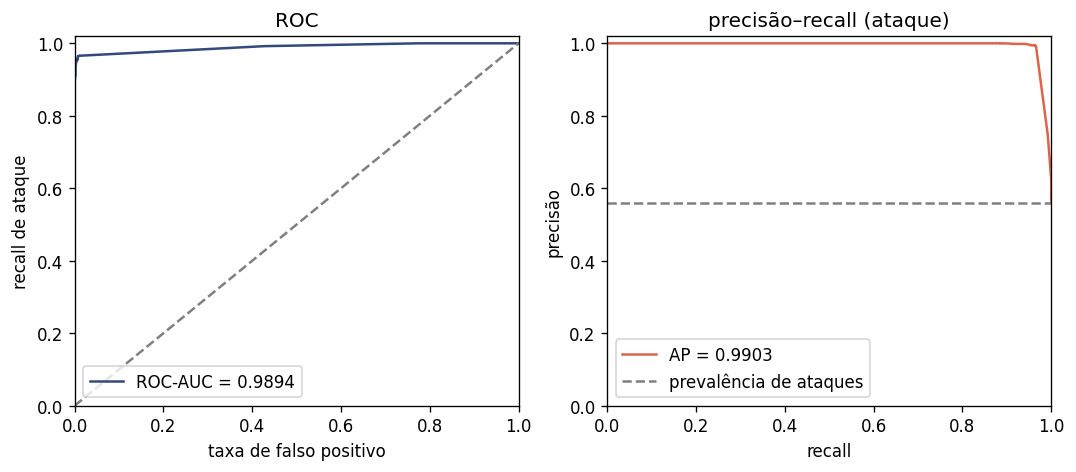

In [8]:
DISPLAY_NAMES = {
    'Dummy_majoritaria': 'Classe majoritária',
    'Regressao_logistica': 'Regressão logística',
    selected_name: 'Random Forest',
    'Controle_ausencias': 'Somente ausências',
}

test_outputs = {}
for name in DISPLAY_NAMES:
    if name == 'Controle_ausencias':
        probability = missingness_model.predict_proba(missing_flags(X_test))[:, 1]

    else:
        probability = models[name].predict_proba(X_test)[:, 1]

    test_outputs[name] = ((probability >= THRESHOLD).astype('int8'), probability)

test_metrics = pd.DataFrame([{'model': name, **metrics(y_test, *test_outputs[name])} for name in DISPLAY_NAMES])
display(test_metrics[
    ['model', 'accuracy', 'balanced_accuracy', 'macro_f1', 'precision_attack', 'recall_attack', 'false_positive_rate', 'average_precision']
    ].round(4))

test_metrics.to_csv(RESULTS / 'test_metrics.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(list(DISPLAY_NAMES.values()), test_metrics.accuracy, color=['#a5adb7', COLORS['benigno'], COLORS['principal'], COLORS['ataque']])

ax.invert_yaxis()
ax.set(xlim=(0, 1.13), xlabel='acurácia no teste reservado', title='classificação e controle da disponibilidade dos campos')

ax.set_xticks([0, .25, .5, .75, 1], ['0%', '25%', '50%', '75%', '100%'])

for bar, value in zip(bars, test_metrics.accuracy):
    ax.text(value + .014, bar.get_y() + bar.get_height() / 2, f'{value:.2%}', va='center')

save_figure('04_baseline_comparison.png')

y_pred, y_prob = test_outputs[selected_name]
primary_metrics = metrics(y_test, y_pred, y_prob)
assert sum(primary_metrics[k] for k in ('tn', 'fp', 'fn', 'tp')) == len(y_test)

class_report = pd.DataFrame(classification_report(
    y_test, y_pred, labels=[0, 1], target_names=['Benigno', 'Ataque'],
    output_dict=True, zero_division=0)).T

display(class_report.round(4))
class_report.to_csv(RESULTS / 'classification_report.csv', index_label='classe')

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
for ax, norm, title in zip(axes, [None, 'true'], ['contagens no teste', 'proporção por classe real']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, labels=[0, 1], display_labels=['Benigno', 'Ataque'],
        normalize=norm, ax=ax, cmap='Blues', colorbar=False,
        values_format='d' if norm is None else '.2%')
    ax.set(title=title, xlabel='Classe prevista', ylabel='Classe real')
save_figure('05_confusion_matrix.png')

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4))
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color=COLORS['principal'], label=f'ROC-AUC = {primary_metrics["roc_auc"]:.4f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(title='ROC', xlabel='taxa de falso positivo', ylabel='recall de ataque')
precision, recall, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(recall, precision, color=COLORS['ataque'], label=f'AP = {primary_metrics["average_precision"]:.4f}')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='prevalência de ataques')
axes[1].set(title='precisão–recall (ataque)', xlabel='recall', ylabel='precisão')

for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc='lower left')
    
save_figure('06_roc_pr_curves.png')

## 9. Incerteza e fatias de diagnóstico

Um intervalo percentil de 95% é calculado com **500 reamostragens dos grupos de conexão** do teste, e todas as linhas de um grupo são reamostradas juntas. O intervalo quantifica a variabilidade condicional deste teste, não incluindo mudanças de rede, campanhas, seleção de hiperparâmetros ou novos treinamentos. Os grupos também podem continuar dependentes.

Duas fatias pré-definidas são examinadas: registros sem ausências nas medidas numéricas e representações de atributos que não apareceram no treino. As fatias têm distribuições próprias e não substituem o teste principal. Linhas do teste não são removidas para aumentar scores.

In [9]:
def grouped_bootstrap(y_true, prediction, group_ids, point_estimates, n_bootstrap=500):
    unique_groups, inverse = np.unique(group_ids, return_inverse=True)
    n_groups = len(unique_groups)
    cells = np.zeros((n_groups, 4), dtype=np.int64)  # TN, FP, FN, TP por grupo
    cell_code = np.asarray(y_true, dtype=int) * 2 + np.asarray(prediction, dtype=int)
    np.add.at(cells, (inverse, cell_code), 1)

    rng = np.random.default_rng(SEED)
    samples = []

    for _ in range(n_bootstrap):
        tn, fp, fn, tp = cells[rng.integers(0, n_groups, size=n_groups)].sum(axis=0)

        if tn + fp == 0 or tp + fn == 0:
            continue

        f1_attack = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0
        f1_benign = 2 * tn / (2 * tn + fp + fn) if 2 * tn + fp + fn else 0

        samples.append([(tn + tp) / (tn + fp + fn + tp), (f1_attack + f1_benign) / 2, tp / (tp + fn)])

    samples = np.asarray(samples)

    if len(samples) < n_bootstrap * 0.9:
        raise ValueError('bootstrap instável: muitas amostras com classe ausente.')

    names = ['accuracy', 'macro_f1', 'recall_attack']
    return pd.DataFrame([
        {'metric': name, 'point': point_estimates[name],
         'lower_95': np.quantile(samples[:, i], .025), 'upper_95': np.quantile(samples[:, i], .975),
         'valid_resamples': len(samples)}
        for i, name in enumerate(names)
    ])


confidence_intervals = grouped_bootstrap(y_test, y_pred, groups[test_idx], primary_metrics)
display(confidence_intervals.round(4))
confidence_intervals.to_csv(RESULTS / 'confidence_intervals.csv', index=False)

slice_masks = {
    'teste completo': np.ones(len(X_test), dtype=bool),
    'medidas numéricas completas': X_test[NUMERIC].notna().all(axis=1).to_numpy(),
    'atributos não vistos no treino': ~np.isin(feature_hash[test_idx], feature_hash[train_idx]),
}
y_test_values = y_test.to_numpy()
slice_records = []
for name, mask in slice_masks.items():
    if not mask.any():
        continue
    y_slice = y_test_values[mask]
    record = {'slice': name, 'n': int(mask.sum()),
              'benignos': int((y_slice == 0).sum()), 'ataques': int((y_slice == 1).sum())}
    if len(np.unique(y_slice)) == 2:
        record.update(metrics(y_slice, y_pred[mask], y_prob[mask]))
    else:
        record['observacao'] = 'apenas uma classe: métricas binárias comparáveis não calculadas.'
    slice_records.append(record)

slices = pd.DataFrame(slice_records)
display_columns = ['slice', 'n', 'benignos', 'ataques', 'accuracy', 'macro_f1', 'recall_attack']
display(slices[[c for c in display_columns if c in slices]].round(4))
slices.to_csv(RESULTS / 'diagnostic_slices.csv', index=False)

,metric,point,lower_95,upper_95,valid_resamples
0,accuracy,0.9763,0.9697,0.9815,500
1,macro_f1,0.9761,0.9694,0.9813,500
2,recall_attack,0.9646,0.9545,0.9723,500


,slice,n,benignos,ataques,accuracy,macro_f1,recall_attack
0,teste completo,10051,4433,5618,0.9763,0.9761,0.9646
1,medidas numéricas completas,6518,1136,5382,0.9929,0.9876,0.9985
2,atributos não vistos no treino,3876,1134,2742,0.9889,0.9865,0.9974


## 10. Casos, evidências e conclusão

As previsões são exportadas sem IPs, URLs e timestamps. O número da linha permite voltar ao CSV local, se necessário. Exemplos corretos e erros são examinados sem serem removidos do cálculo.

Dificuldades técnicas observadas: schema heterogêneo, ausências relacionadas à classe e duplicatas.

In [10]:
predictions = pd.DataFrame({
    'row_id_csv': df['_row_id'].iloc[test_idx].to_numpy(),
    'grupo': groups[test_idx],
    'label_real': y_test.to_numpy(),
    'label_previsto': y_pred,
    'probabilidade_ataque': y_prob,
    'tipo_resultado': np.array(['TN', 'FP', 'FN', 'TP'])[y_test.to_numpy() * 2 + y_pred],
})
predictions.to_csv(RESULTS / 'test_predictions.csv', index=False)

examples = predictions.groupby('tipo_resultado', group_keys=False).head(3)
display(examples)
examples.to_csv(RESULTS / 'prediction_examples.csv', index=False)

manifest = {
    'executed_utc': datetime.now(timezone.utc).isoformat(),
    'data_sha256': data_hash,
    'seed': SEED,
    'threshold': THRESHOLD,
    'selected_model': selected_name,
    'selected_rf_parameters': {k: selected_config[k] for k in [
        'n_estimators', 'max_depth', 'min_samples_leaf', 'class_weight',
        'max_features', 'random_state', 'n_jobs']},
    'environment': environment,
}

(RESULTS / 'run_manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')

print(
    f'Modelo: {selected_name} | Teste: {len(y_test):,} registros\n'
    f'Acurácia: {primary_metrics["accuracy"]:.2%} | Macro-F1: {primary_metrics["macro_f1"]:.4f} | '
    f'Precisão de ataque: {primary_metrics["precision_attack"]:.2%} | '
    f'Recall de ataque: {primary_metrics["recall_attack"]:.2%}\n'
    f'Erros: {primary_metrics["fp"]} falsos alarmes e {primary_metrics["fn"]} ataques não identificados.\n\n'
)

print('Figuras:', FIGURES)
print('Resultados:', RESULTS)

,row_id_csv,grupo,label_real,label_previsto,probabilidade_ataque,tipo_resultado
0,15,19,0,1,0.798943,FP
1,18,19,0,1,0.798943,FP
2,19,31100,0,1,0.885216,FP
15,146,27412,0,0,0.057384,TN
16,151,27417,0,0,0.057384,TN
17,152,27417,0,0,0.024688,TN
4433,26286,19,1,1,0.798943,TP
4434,26288,31232,1,1,0.950816,TP
4435,26291,31366,1,1,0.763435,TP
4459,26415,23372,1,0,0.057384,FN


Modelo: RandomForest_2 | Teste: 10,051 registros
Acurácia: 97.63% | Macro-F1: 0.9761 | Precisão de ataque: 99.29% | Recall de ataque: 96.46%
Erros: 39 falsos alarmes e 199 ataques não identificados.


Figuras: /home/ari/network-intrusion-detection/reports/figures
Resultados: /home/ari/network-intrusion-detection/reports/results


## 11. Referências

1. Moreira Carneiro, José & Oliveira, Nuno & Sousa, Norberto & Maia, Eva & Praça, Isabel. (2021). Machine Learning for Network-based Intrusion Detection Systems: an Analysis of the CIDDS-001 Dataset. 10.48550/arXiv.2107.02753.
2. R. Sommer and V. Paxson, "Outside the Closed World: On Using Machine Learning for Network Intrusion Detection," 2010 IEEE Symposium on Security and Privacy, Oakland, CA, USA, 2010, pp. 305-316, doi: 10.1109/SP.2010.25.
3. Shibly, M. Z. A. et al. (2026). Empirical Bernstein Certified Bandit-KL Mixing with Tree Stacking for Explainable Federated Intrusion Detection. 10.1109/FUZZ69877.2026.11626376.
4. Breiman, Leo. (2001). Random Forests. Machine Learning, 45(1), 5–32. 10.1023/A:1010933404324.
5. Pedregosa, Fabian & Varoquaux, Gael & Gramfort, Alexandre & Michel, Vincent & Thirion, Bertrand & Grisel, Olivier & Blondel, Mathieu & Prettenhofer, Peter & Weiss, Ron & Dubourg, Vincent & Vanderplas, Jake & Passos, Alexandre & Cournapeau, David & Brucher, Matthieu & Perrot, Matthieu & Duchesnay, Edouard & Louppe, Gilles. (2012). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research. 12.

Este material é um experimento educacional e uma revisão narrativa direcionada, não uma revisão sistemática nem uma demonstração de que o modelo supera o estado da arte.